In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('portugal_listinigs.csv')
df.head()

C:\Users\jmlim\AppData\Local\Temp\ipykernel_8612\3582540689.py:5: DtypeWarning: Columns (6,8,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('portugal_listinigs.csv')


,Price,District,City,Town,Type,EnergyCertificate,Floor,Parking,HasParking,ConstructionYear,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,2nd Floor,1.0,True,NaN,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0
1,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,1st Floor,0.0,False,1990.0,...,True,NaN,0.0,NaN,NaN,NaN,27.0,NaN,NaN,1.0
2,580000.0,Faro,Vila do Bispo,Budens,Apartment,D,3rd Floor,1.0,True,2003.0,...,False,NaN,2.0,NaN,NaN,NaN,84.0,NaN,NaN,2.0
3,350000.0,Faro,Portimão,Portimão,Apartment,C,4th Floor,0.0,False,1985.0,...,True,NaN,2.0,NaN,NaN,NaN,68.0,NaN,NaN,1.0
4,175000.0,Faro,Faro,Faro (Sé e São Pedro),House,NC,NaN,0.0,False,1950.0,...,False,NaN,4.0,NaN,NaN,NaN,78.0,NaN,NaN,2.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120826 entries, 0 to 120825
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  120545 non-null  float64
 1   District               120826 non-null  object 
 2   City                   120826 non-null  object 
 3   Town                   120824 non-null  object 
 4   Type                   120810 non-null  object 
 5   EnergyCertificate      120812 non-null  object 
 6   Floor                  27929 non-null   object 
 7   Parking                120632 non-null  float64
 8   HasParking             68215 non-null   object 
 9   ConstructionYear       78228 non-null   float64
 10  TotalArea              113782 non-null  float64
 11  GrossArea              27638 non-null   float64
 12  EnergyEfficiencyLevel  52579 non-null   object 
 13  PublishDate            19224 non-null   object 
 14  Garage                 52579 non-nul

In [4]:
df.describe()

,Price,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.205450e+05,120632.000000,78228.000000,1.137820e+05,2.763800e+04,67802.000000,35428.000000,46621.000000,9.252900e+04,3.209000e+04,2.097700e+04,115096.000000
mean,3.674658e+05,0.570520,1988.993596,5.742814e+05,2.789733e+03,3.151220,2.680253,0.412196,1.508726e+03,6.726420e+04,3.495683e+03,1.516273
std,4.024606e+06,0.870374,26.690061,1.821361e+08,1.153670e+05,10.880886,1.863235,1.021265,3.684470e+04,5.784162e+06,1.321013e+05,1.719349
min,1.000000e+00,0.000000,1900.000000,-7.196067e+06,-7.000000e+00,0.000000,0.000000,-15.000000,0.000000e+00,0.000000e+00,-1.000000e+00,-13.000000
25%,7.990000e+04,0.000000,1972.000000,9.400000e+01,1.000000e+02,2.000000,2.000000,0.000000,8.000000e+01,2.880000e+02,1.058000e+02,0.000000
50%,2.000000e+05,0.000000,1994.000000,1.710000e+02,1.640000e+02,3.000000,3.000000,0.000000,1.200000e+02,7.565000e+02,1.730000e+02,1.000000
75%,3.921000e+05,1.000000,2008.000000,5.800000e+02,2.940000e+02,4.000000,3.000000,0.000000,2.120000e+02,3.174750e+03,3.114500e+02,2.000000
max,1.380000e+09,3.000000,2024.000000,6.142007e+10,1.275000e+07,2751.000000,21.000000,59.000000,5.429000e+06,9.923010e+08,1.275000e+07,90.000000


In [5]:
# Drop values bellow 0 or 0 in the columns where that is not possible
df.drop(df[df['TotalArea'] <= 0].index, inplace=True)
df.drop(df[df['GrossArea'] <= 0].index, inplace=True)
df.drop(df[df['BuiltArea'] <= 0].index, inplace=True)
df.drop(df[df['NumberOfBathrooms'] < 0].index, inplace=True)
df.drop(df[df['NumberOfWC'] < 0].index, inplace=True)

In [6]:
def show_missing_data_with_percent(df):
    missing_values = df.isna().sum()
    missing_percentage = round((df.isna().sum() / len(df)) * 100, 2)
    missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print(missing_data)
show_missing_data_with_percent(df)

                       Missing Values  Percentage
Price                             279        0.23
District                            0        0.00
City                                0        0.00
Town                                2        0.00
Type                               16        0.01
EnergyCertificate                  14        0.01
Floor                           92307       77.17
Parking                           194        0.16
HasParking                      52262       43.69
ConstructionYear                42150       35.24
TotalArea                        7043        5.89
GrossArea                       92741       77.53
EnergyEfficiencyLevel           67392       56.34
PublishDate                    100471       83.99
Garage                          67392       56.34
Elevator                           32        0.03
ElectricCarsCharging            67392       56.34
TotalRooms                      52769       44.11
NumberOfBedrooms                84408       70.56


In [7]:
df.shape

(119622, 25)

In [8]:
df.dropna(subset=['Price', 'Town', 'EnergyCertificate', 'Elevator', 'Type', 'Parking'], inplace=True)
df.isna().sum()

Price                         0
District                      0
City                          0
Town                          0
Type                          0
EnergyCertificate             0
Floor                     91924
Parking                       0
HasParking                52090
ConstructionYear          41899
TotalArea                  7005
GrossArea                 92363
EnergyEfficiencyLevel     67055
PublishDate              100006
Garage                    67055
Elevator                      0
ElectricCarsCharging      67055
TotalRooms                52631
NumberOfBedrooms          84045
NumberOfWC                73002
ConservationStatus       104218
LivingArea                28089
LotSize                   87450
BuiltArea                 98436
NumberOfBathrooms          5658
dtype: int64

In [9]:
df.shape

(119145, 25)

In [10]:
# Actual unique values for each column
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for {column}:")
        print(df[column].unique())
        print("\n")

Unique values for District:
['Faro' 'Vila Real' 'Porto' 'Lisboa' 'Guarda' 'Leiria' 'Viseu' 'Setúbal'
 'Coimbra' 'Castelo Branco' 'Ilha Terceira' 'Beja' 'Santarém' 'Aveiro'
 'Évora' 'Braga' 'Ilha de São Miguel' 'Portalegre' 'Bragança'
 'Viana do Castelo' 'Ilha da Madeira' 'Ilha de Porto Santo'
 'Ilha de Santa Maria' 'Ilha de São Jorge' 'Z - Fora de Portugal']


Unique values for City:
['São Brás de Alportel' 'Albufeira' 'Vila do Bispo' 'Portimão' 'Faro'
 'Loulé' 'Lagos' 'Alcoutim' 'Valpaços' 'Lagoa (Algarve)' 'Castro Marim'
 'Olhão' 'Vila Real de Santo António' 'Silves' 'Tavira' 'Aljezur' 'Porto'
 'Monchique' 'Sintra' 'Seia' 'Paços de Ferreira' 'Almeida' 'Gouveia'
 'Celorico da Beira' 'Mêda' 'Guarda' 'Trancoso' 'Matosinhos' 'Lisboa'
 'Fornos de Algodres' 'Ansião' 'Pinhel' 'Manteigas'
 'Figueira de Castelo Rodrigo' 'Tondela' 'Aguiar da Beira'
 'Vila Nova de Foz Côa' 'Setúbal' 'Sabugal' 'Azambuja' 'Coimbra'
 'Amarante' 'Marinha Grande' 'Sertã' 'Gondomar' 'Praia da Vitória'
 'Alvito' 'Seix

In [11]:
missing = df.isnull().sum()/len(df)
missing = missing[missing >= 0.8]
missing.sort_values(inplace=True)
print(missing)
df.drop(columns=missing.index, inplace=True)

BuiltArea             0.826187
PublishDate           0.839364
ConservationStatus    0.874716
dtype: float64


In [12]:
show_missing_data_with_percent(df)
# Correct the data types
df['City'] = df['City'].astype(str)
df['Town'] = df['Town'].astype(str)
df['Type'] = df['Type'].astype(str)
df['EnergyCertificate'] = df['EnergyCertificate'].astype(str)
df.dtypes

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                           91924       77.15
Parking                             0        0.00
HasParking                      52090       43.72
ConstructionYear                41899       35.17
TotalArea                        7005        5.88
GrossArea                       92363       77.52
EnergyEfficiencyLevel           67055       56.28
Garage                          67055       56.28
Elevator                            0        0.00
ElectricCarsCharging            67055       56.28
TotalRooms                      52631       44.17
NumberOfBedrooms                84045       70.54
NumberOfWC                      73002       61.27


Price                    float64
District                  object
City                      object
Town                      object
Type                      object
EnergyCertificate         object
Floor                     object
Parking                  float64
HasParking                object
ConstructionYear         float64
TotalArea                float64
GrossArea                float64
EnergyEfficiencyLevel     object
Garage                    object
Elevator                  object
ElectricCarsCharging      object
TotalRooms               float64
NumberOfBedrooms         float64
NumberOfWC               float64
LivingArea               float64
LotSize                  float64
NumberOfBathrooms        float64
dtype: object

In [13]:
show_missing_data_with_percent(df)
# Correct the data types
df['City'] = df['City'].astype(str)
df['Town'] = df['Town'].astype(str)
df['Type'] = df['Type'].astype(str)
df['EnergyCertificate'] = df['EnergyCertificate'].astype(str)
df.dtypes

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                           91924       77.15
Parking                             0        0.00
HasParking                      52090       43.72
ConstructionYear                41899       35.17
TotalArea                        7005        5.88
GrossArea                       92363       77.52
EnergyEfficiencyLevel           67055       56.28
Garage                          67055       56.28
Elevator                            0        0.00
ElectricCarsCharging            67055       56.28
TotalRooms                      52631       44.17
NumberOfBedrooms                84045       70.54
NumberOfWC                      73002       61.27


Price                    float64
District                  object
City                      object
Town                      object
Type                      object
EnergyCertificate         object
Floor                     object
Parking                  float64
HasParking                object
ConstructionYear         float64
TotalArea                float64
GrossArea                float64
EnergyEfficiencyLevel     object
Garage                    object
Elevator                  object
ElectricCarsCharging      object
TotalRooms               float64
NumberOfBedrooms         float64
NumberOfWC               float64
LivingArea               float64
LotSize                  float64
NumberOfBathrooms        float64
dtype: object

(119145, 22)


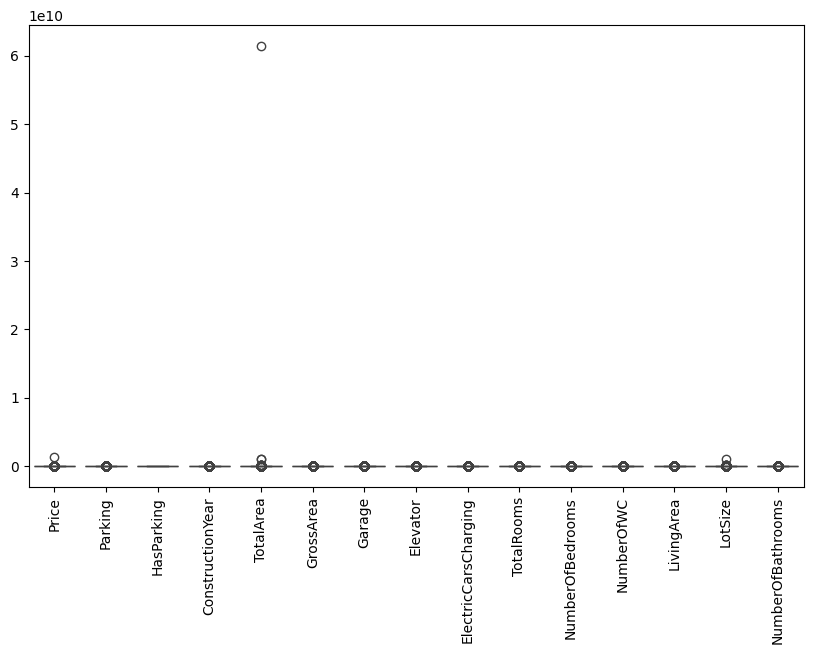

In [14]:
# Display the shape of the dataframe before removing outliers
print(df.shape)
#check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [15]:
# Select float64 columns
df_float64 = df.select_dtypes(include=['float64'])

# Calculate mean and standard deviation for each float64 column
mean_values = df_float64.mean()
std_values = df_float64.std()

# Define a function to identify outliers
def is_outlier(value, mean, std, threshold=3):
    return abs(value - mean) > threshold * std

# Identify and remove outliers
for column in df_float64.columns:
    mean = mean_values[column]
    std = std_values[column]
    df = df[~df[column].apply(is_outlier, args=(mean, std))]

(116816, 22)


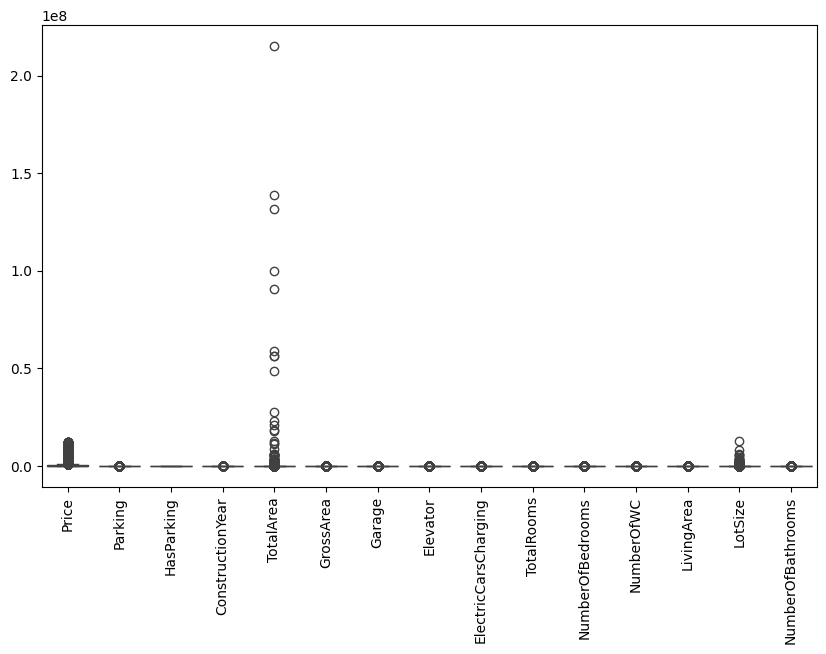

In [16]:
# Display the shape of the dataframe after removing outliers
print(df.shape)
# Check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [17]:
# drop the variables that are not valuable
df.drop(columns=['EnergyEfficiencyLevel'], inplace=True)

# Label enconding

In [18]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
label_encoder = LabelEncoder()

# One-hot encoding may cause dimensionality explosion due to the high number of unique values.
# Target encoding or frequency encoding reduces dimensionality while retaining meaningful information.
target_encoder = TargetEncoder()
df['District'] = target_encoder.fit_transform(df['District'], df['Price'])
df['City'] = target_encoder.fit_transform(df['City'], df['Price'])
df['Town'] = target_encoder.fit_transform(df['Town'], df['Price'])

# This avoids introducing ordinal relationships and works well with a small number of categories.
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df = pd.get_dummies(df, columns=['EnergyCertificate'], drop_first=True)
df = pd.get_dummies(df, columns=['Floor'], drop_first=True)
df = pd.get_dummies(df, columns=['HasParking'], drop_first=True)
df = pd.get_dummies(df, columns=['Garage'], drop_first=True)
df = pd.get_dummies(df, columns=['Elevator'], drop_first=True)
df = pd.get_dummies(df, columns=['ElectricCarsCharging'], drop_first=True)

In [19]:
df

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,250000.0,454911.963023,325455.205179,325455.205179,1.0,NaN,114.0,NaN,2.0,NaN,...,False,False,False,False,False,False,True,False,True,False
1,9500.0,454911.963023,268298.178218,221274.918033,0.0,1990.0,27.0,NaN,0.0,NaN,...,False,False,False,False,False,False,False,False,True,False
2,580000.0,454911.963023,440389.015719,536644.244790,1.0,2003.0,84.0,NaN,2.0,NaN,...,False,False,False,False,False,False,True,False,False,False
3,350000.0,454911.963023,424131.031329,379171.041445,0.0,1985.0,68.0,NaN,2.0,NaN,...,False,False,False,False,False,False,False,False,True,False
4,175000.0,454911.963023,562882.079548,521709.141712,0.0,1950.0,78.0,NaN,4.0,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120821,225000.0,183341.026921,219075.301205,398777.585669,1.0,2003.0,122.0,NaN,NaN,3.0,...,False,False,False,False,False,False,False,False,False,False
120822,46500.0,183341.026921,219075.301205,126259.087484,0.0,1987.0,51.0,NaN,NaN,2.0,...,False,False,False,False,False,False,False,False,False,False
120823,80000.0,183341.026921,152441.496717,280294.201362,0.0,1979.0,90.0,NaN,8.0,3.0,...,False,False,False,False,False,False,False,True,False,False
120824,12500.0,183341.026921,176963.860606,135218.974202,0.0,1974.0,28.0,NaN,NaN,2.0,...,False,False,False,False,False,False,False,False,False,False


### Save the Label Enconder state


In [20]:
import pickle

# Save the LabelEncoder to a file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
    
# To read it back
# # Load the LabelEncoder from the file
# with open('label_encoder.pkl', 'rb') as f:
#     loaded_label_encoder = pickle.load(f)

### Scaling numeric variables

In [21]:
from sklearn.preprocessing import StandardScaler

# Assuming df is your original DataFrame
scaler = StandardScaler()

# Select only numeric columns
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_numeric = df.select_dtypes(include=numerics)

# Scale the numeric columns
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)

# Combine scaled numeric columns with non-numeric columns
df_non_numeric = df.select_dtypes(exclude=numerics)
df_combined = pd.concat([df_scaled, df_non_numeric], axis=1)

# If you want to keep the original column order
df_combined = df_combined[df.columns]
df = df_combined

In [22]:
df

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,-0.160561,0.837149,-0.039872,-0.096478,0.501384,NaN,-0.013349,NaN,-0.477109,NaN,...,False,False,False,False,False,False,True,False,True,False
1,-0.624510,0.837149,-0.321829,-0.552998,-0.653973,0.026861,-0.013433,NaN,-1.441367,NaN,...,False,False,False,False,False,False,False,False,True,False
2,0.476042,0.837149,0.527099,0.828956,0.501384,0.523745,-0.013378,NaN,-0.477109,NaN,...,False,False,False,False,False,False,True,False,False,False
3,0.032349,0.837149,0.446898,0.138906,-0.653973,-0.164248,-0.013394,NaN,-0.477109,NaN,...,False,False,False,False,False,False,False,False,True,False
4,-0.305244,0.837149,1.131361,0.763511,-0.653973,-1.502011,-0.013384,NaN,0.487148,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120821,-0.208789,-1.031658,-0.564647,0.224822,0.501384,0.523745,-0.013341,NaN,NaN,0.328977,...,False,False,False,False,False,False,False,False,False,False
120822,-0.553134,-1.031658,-0.564647,-0.969359,-0.653973,-0.087804,-0.013410,NaN,NaN,-0.372216,...,False,False,False,False,False,False,False,False,False,False
120823,-0.488509,-1.031658,-0.893353,-0.294374,-0.653973,-0.393578,-0.013372,NaN,2.415664,0.328977,...,False,False,False,False,False,False,False,True,False,False
120824,-0.618723,-1.031658,-0.772384,-0.930096,-0.653973,-0.584688,-0.013432,NaN,NaN,-0.372216,...,False,False,False,False,False,False,False,False,False,False


## Fill Missing values with KNNImputer


In [23]:
# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,-0.160561,0.837149,-0.039872,-0.096478,0.501384,1.257604,-0.013349,-0.129246,-0.477109,-0.091739,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.624510,0.837149,-0.321829,-0.552998,-0.653973,0.026861,-0.013433,-0.148748,-1.441367,-1.774602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.476042,0.837149,0.527099,0.828956,0.501384,0.523745,-0.013378,-0.132155,-0.477109,0.048500,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.032349,0.837149,0.446898,0.138906,-0.653973,-0.164248,-0.013394,-0.141543,-0.477109,-1.073409,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.305244,0.837149,1.131361,0.763511,-0.653973,-1.502011,-0.013384,-0.106141,0.487148,0.048500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116811,-0.208789,-1.031658,-0.564647,0.224822,0.501384,0.523745,-0.013341,-0.131497,0.776426,0.328977,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116812,-0.553134,-1.031658,-0.564647,-0.969359,-0.653973,-0.087804,-0.013410,-0.144522,-0.284258,-0.372216,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116813,-0.488509,-1.031658,-0.893353,-0.294374,-0.653973,-0.393578,-0.013372,-0.123114,2.415664,0.328977,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
116814,-0.618723,-1.031658,-0.772384,-0.930096,-0.653973,-0.584688,-0.013432,-0.131082,-0.284258,-0.372216,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# Save the KNNImputer to a file
df_imputed.to_csv('proceced_and_imputed.csv', index=False)
show_missing_data_with_percent(df)

                           Missing Values  Percentage
Price                                   0         0.0
District                                0         0.0
City                                    0         0.0
Town                                    0         0.0
Parking                                 0         0.0
...                                   ...         ...
Floor_Triplex                           0         0.0
HasParking_True                         0         0.0
Garage_True                             0         0.0
Elevator_True                           0         0.0
ElectricCarsCharging_True               0         0.0

[66 rows x 2 columns]


In [25]:
# df_imputed = pd.read_csv('proceced_and_imputed.csv')
df = df_imputed

In [26]:
show_missing_data_with_percent(df)


                           Missing Values  Percentage
Price                                   0         0.0
District                                0         0.0
City                                    0         0.0
Town                                    0         0.0
Parking                                 0         0.0
...                                   ...         ...
Floor_Triplex                           0         0.0
HasParking_True                         0         0.0
Garage_True                             0         0.0
Elevator_True                           0         0.0
ElectricCarsCharging_True               0         0.0

[66 rows x 2 columns]


In [27]:
# Dataframe summary
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (116816, 66)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.0,8094,4374,116816,-0.642835,23.470942,7.627556e-17,1.000004,-0.160561,-0.624510,0.476042
District,float64,0,0.0,8094,24,116816,-1.673604,1.451846,-4.710350e-16,1.000004,0.837149,0.837149,0.837149
City,float64,0,0.0,8094,271,116816,-1.448766,3.446990,5.741956e-17,1.000004,-0.039872,-0.321829,0.527099
Town,float64,0,0.0,8094,2197,116816,-1.396991,4.670278,-5.304010e-17,1.000004,-0.096478,-0.552998,0.828956
Parking,float64,0,0.0,8094,4,116816,-0.653973,2.812096,1.849105e-17,1.000004,0.501384,-0.653973,0.501384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Floor_Triplex,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.311327e-04,0.015201,0.000000,0.000000,0.000000
HasParking_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.551363e-01,0.435940,1.000000,0.000000,1.000000
Garage_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,7.298658e-02,0.260116,0.000000,0.000000,0.000000
Elevator_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.445213e-01,0.429805,1.000000,1.000000,0.000000


In [28]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (116816, 66)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.0,8094,4374,116816,-0.642835,23.470942,7.627556e-17,1.000004,-0.160561,-0.624510,0.476042
District,float64,0,0.0,8094,24,116816,-1.673604,1.451846,-4.710350e-16,1.000004,0.837149,0.837149,0.837149
City,float64,0,0.0,8094,271,116816,-1.448766,3.446990,5.741956e-17,1.000004,-0.039872,-0.321829,0.527099
Town,float64,0,0.0,8094,2197,116816,-1.396991,4.670278,-5.304010e-17,1.000004,-0.096478,-0.552998,0.828956
Parking,float64,0,0.0,8094,4,116816,-0.653973,2.812096,1.849105e-17,1.000004,0.501384,-0.653973,0.501384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Floor_Triplex,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.311327e-04,0.015201,0.000000,0.000000,0.000000
HasParking_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.551363e-01,0.435940,1.000000,0.000000,1.000000
Garage_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,7.298658e-02,0.260116,0.000000,0.000000,0.000000
Elevator_True,float64,0,0.0,8094,2,116816,0.000000,1.000000,2.445213e-01,0.429805,1.000000,1.000000,0.000000


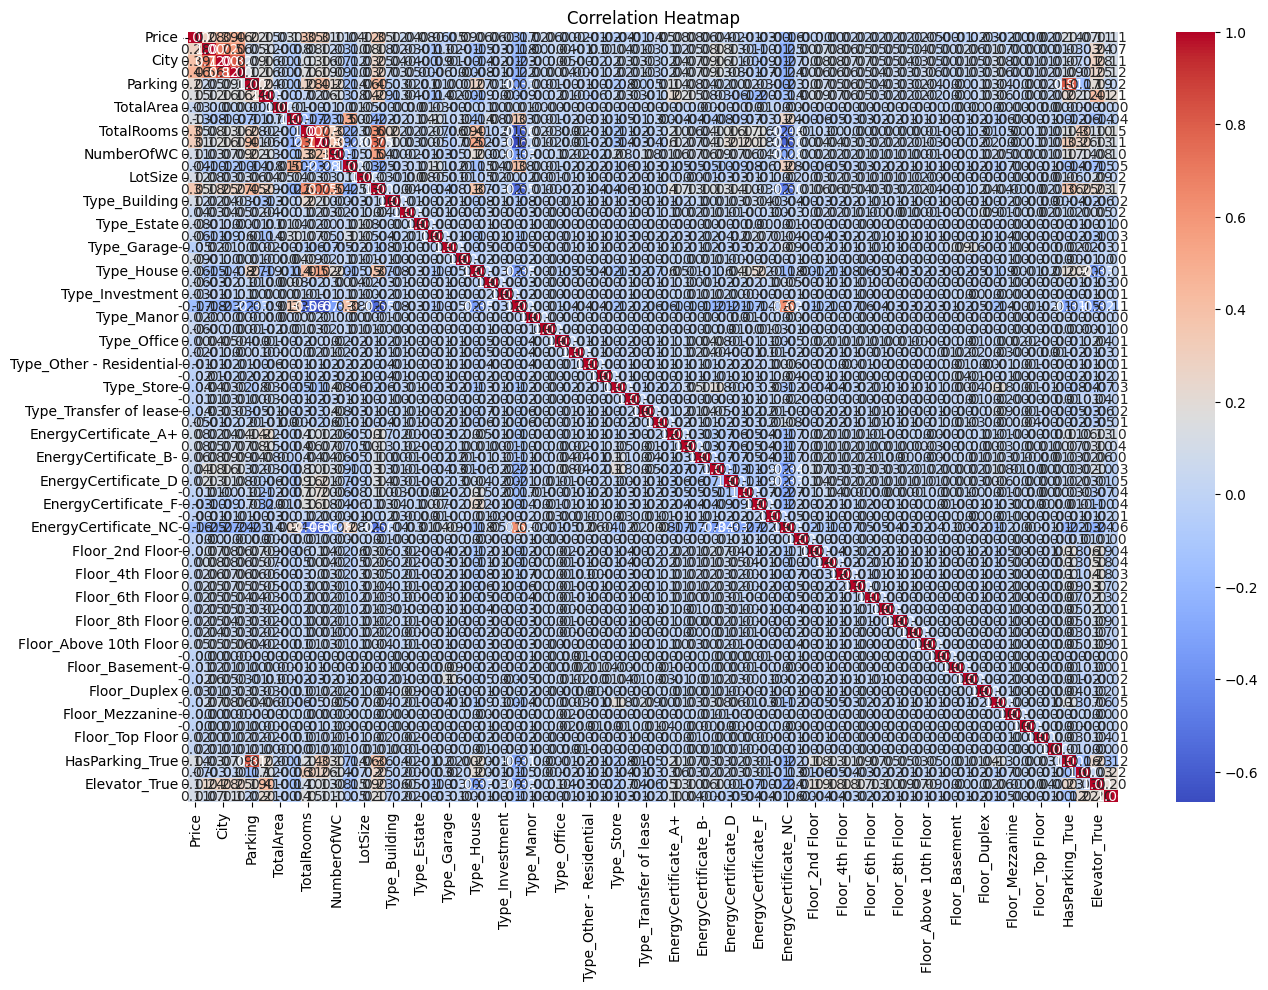

In [29]:
#correalation matrix
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# SHAP feature importance analysis

In [30]:
%pip install shap
%pip install xgboost
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split


# Calculate correlation with the target variable
correlation = df.corr()['Price'].sort_values(ascending=False)
print(correlation)


X = df.drop(columns=['Price'])
y = df['Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Price                     1.000000
Town                      0.459723
City                      0.391497
TotalRooms                0.352576
NumberOfBathrooms         0.345652
                            ...   
Type_Store               -0.042013
Type_Transfer of lease   -0.044551
Type_Garage              -0.048965
EnergyCertificate_NC     -0.164457
Type_Land                -0.168449
Name: Price, Length: 66, dtype: float64


# Task 2
Train  a  glass-box  model  on  your  case  study  and  critically  analyze  the  interpretability  provided  by 
 the obtained model. 

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Train a Random Forest classifier
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline model: Predict the mean of the target variable
y_baseline = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_rmse = mean_squared_error(y_test, y_baseline, squared=False)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Baseline Mean Squared Error: {baseline_mse}")
print(f"Baseline Root Mean Squared Error: {baseline_rmse}")
print(f"Baseline Mean Absolute Error: {baseline_mae}")
print(f"Baseline R-squared: {baseline_r2}")

Mean Squared Error: 0.39941098475397857
Root Mean Squared Error: 0.6319897030442653
Mean Absolute Error: 0.1962836977536843
R-squared: 0.5929509575933003
Baseline Mean Squared Error: 0.9812361221587772
Baseline Root Mean Squared Error: 0.9905736328808562
Baseline Mean Absolute Error: 0.5280312624023895
Baseline R-squared: -5.987457136757968e-07


C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Task 3
Train  a  black-box  model  on  your  case  study  and  then  apply  post-hoc  XAI  techniques  ,  as 
 described below. 

In [33]:
import numpy as np
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(verbose=0, random_seed=42)
catboost_model.fit(X_train, y_train)

y_pred = catboost_model.predict(X_test)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline model: Predict the mean of the target variable
y_baseline = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_rmse = mean_squared_error(y_test, y_baseline, squared=False)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Baseline Mean Squared Error: {baseline_mse}")
print(f"Baseline Root Mean Squared Error: {baseline_rmse}")
print(f"Baseline Mean Absolute Error: {baseline_mae}")
print(f"Baseline R-squared: {baseline_r2}")

Mean Squared Error: 0.1850184680742463
Root Mean Squared Error: 0.43013773151659956
Mean Absolute Error: 0.18763218755465297
R-squared: 0.8114433675288989
Baseline Mean Squared Error: 0.9812361221587772
Baseline Root Mean Squared Error: 0.9905736328808562
Baseline Mean Absolute Error: 0.5280312624023895
Baseline R-squared: -5.987457136757968e-07


C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Task 3.1
Apply  at  least  one  simplification-based  technique  and  assess  how  well  it  approximates 
 the black-box model.

### Global Surrogate: Generalized Additive Model (GAM)
- Captures non-linear relationships for individual features while remaining interpretable.
- Allows for partial dependence plots of individual features.

In [35]:
from pygam import LinearGAM, s, l

terms = s(0)
for i in range(1, X_train.shape[1]):
    terms += s(i)

# Define the GAM with smooth terms for each feature
gam = LinearGAM(terms)

# Train the GAM
gam.fit(X_test.values, y_pred)

# Predictions from GAM
y_gam_pred = gam.predict(X_test.values)

In [36]:
# Evaluate the model
mse = mean_squared_error(y_pred, y_gam_pred)
rmse = mean_squared_error(y_pred, y_gam_pred, squared=False)
mae = mean_absolute_error(y_pred, y_gam_pred)
r2 = r2_score(y_pred, y_gam_pred)

print(f"Surrogate Model RMSE: {rmse}")
print(f"Surrogate Model MAE: {mae}")
print(f"Surrogate Model R²: {r2:.2f}")
print(f"Surrogate Model MSE: {mse:.2f}")

Surrogate Model RMSE: 0.5057706665441336
Surrogate Model MAE: 0.25373532674311594
Surrogate Model R²: 0.66
Surrogate Model MSE: 0.26


C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


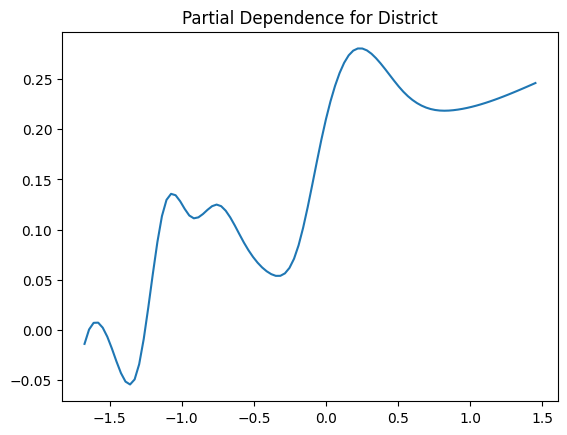

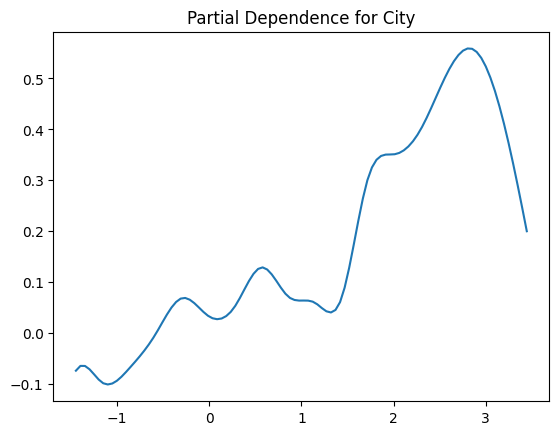

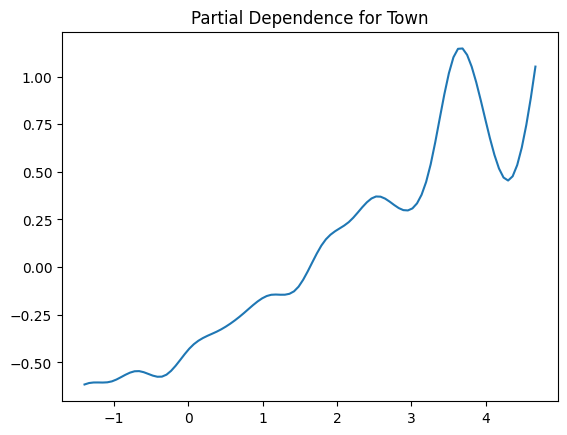

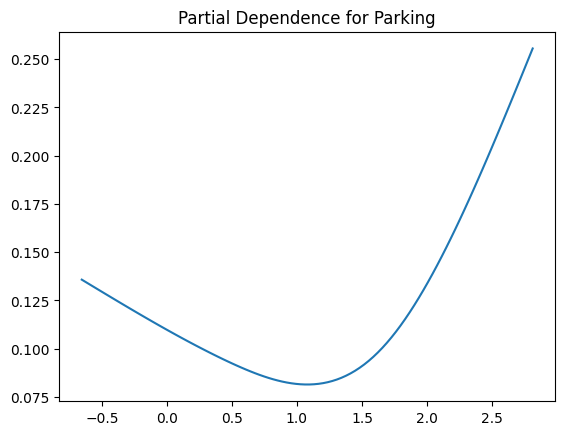

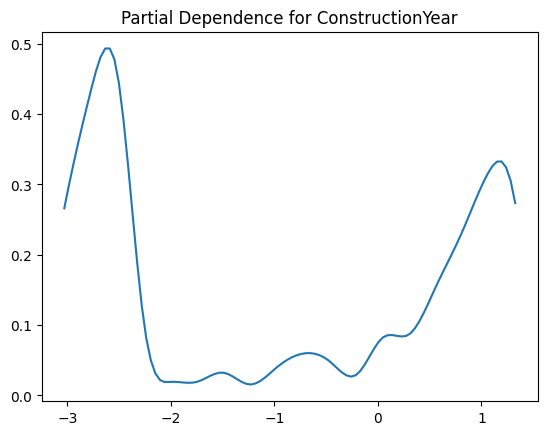

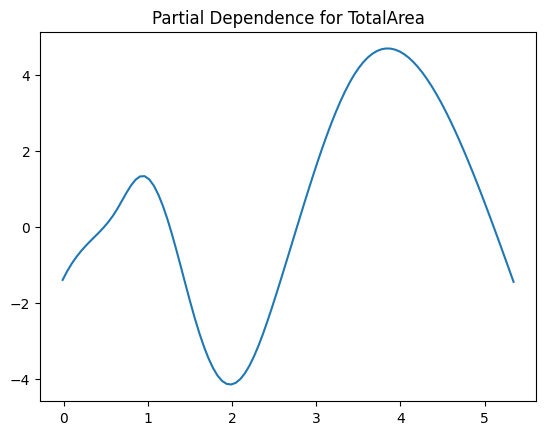

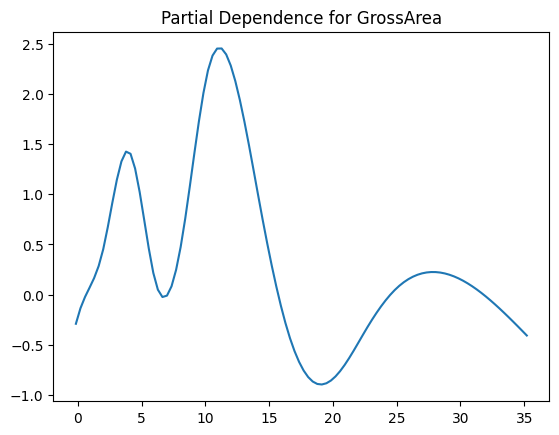

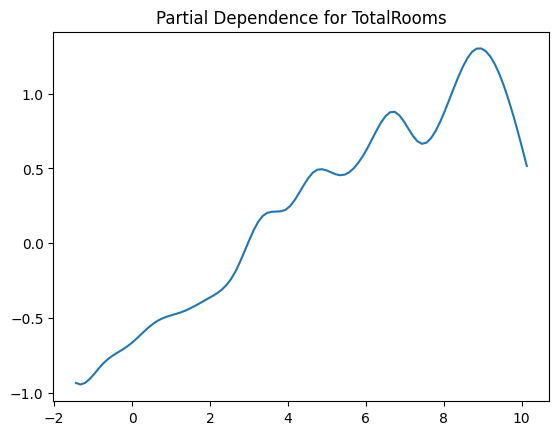

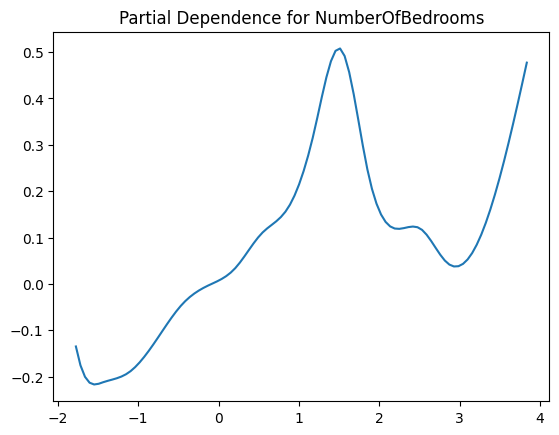

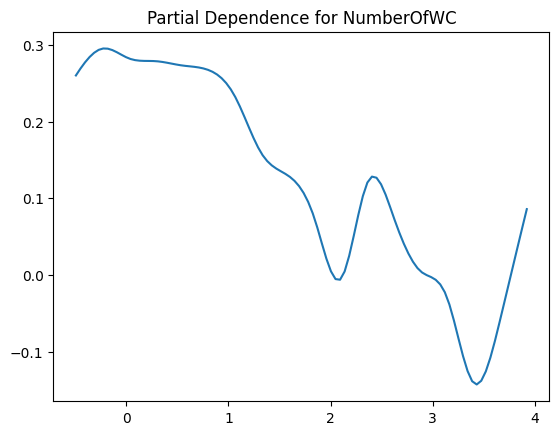

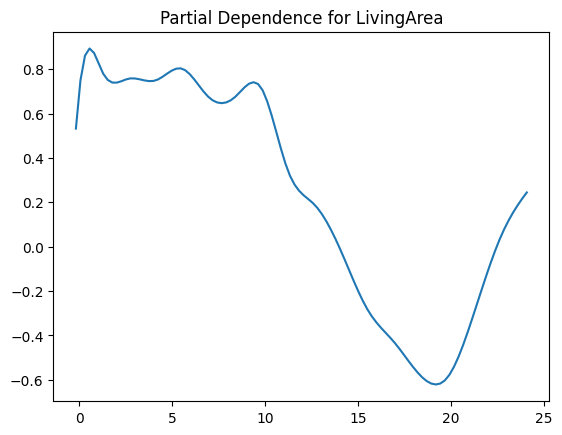

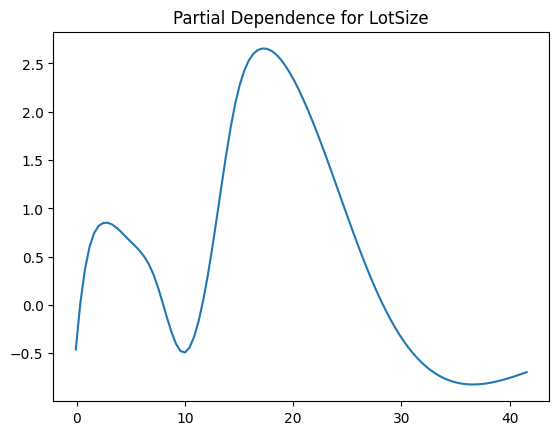

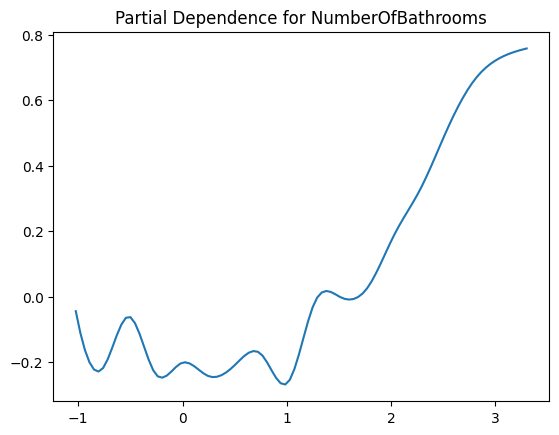

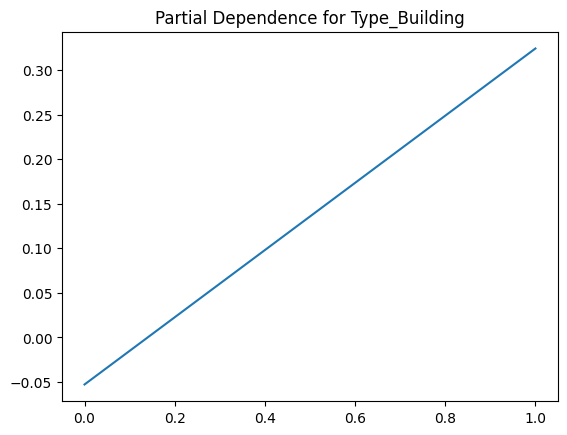

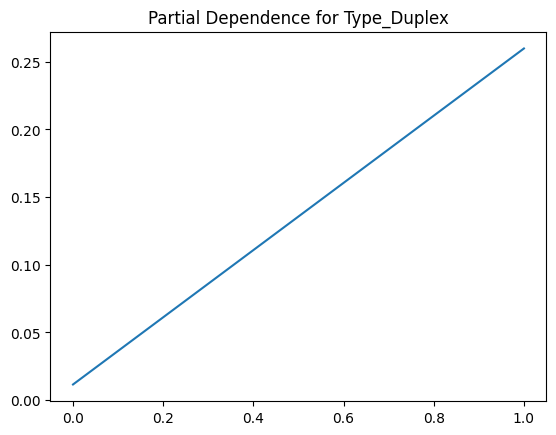

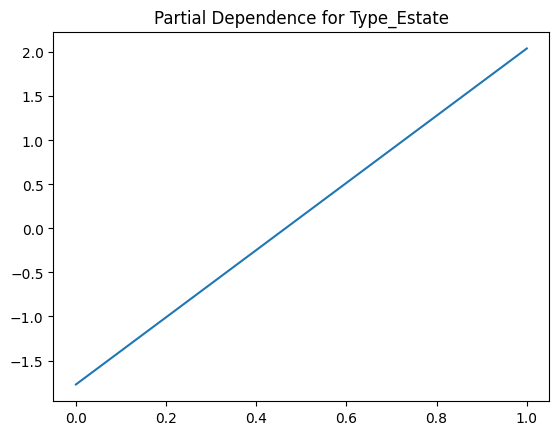

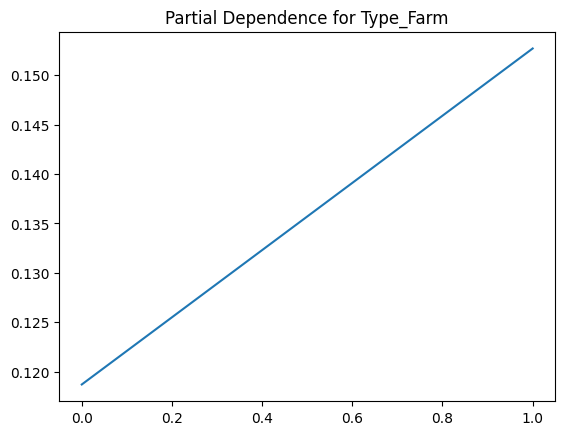

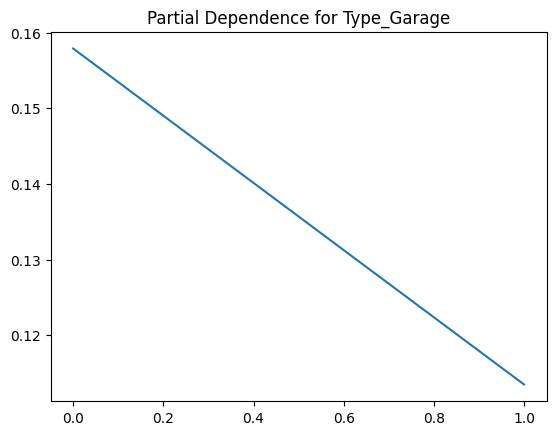

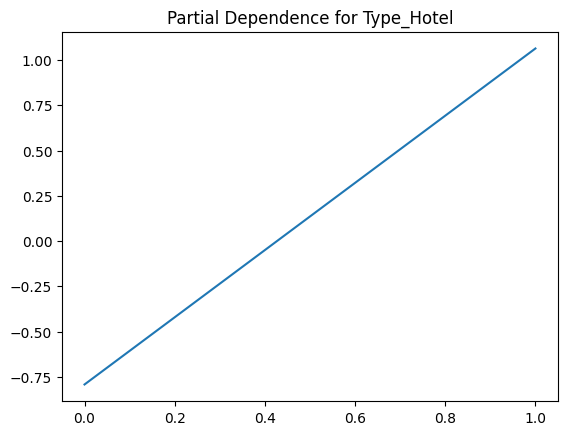

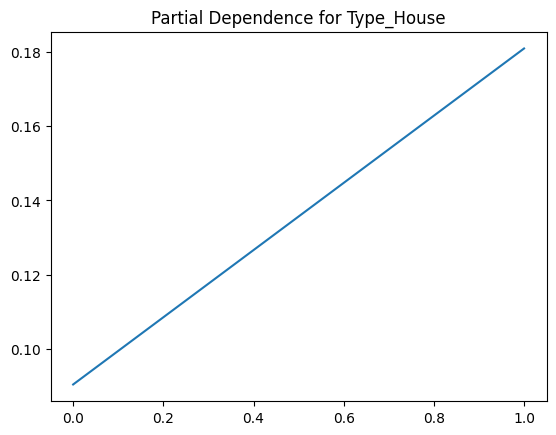

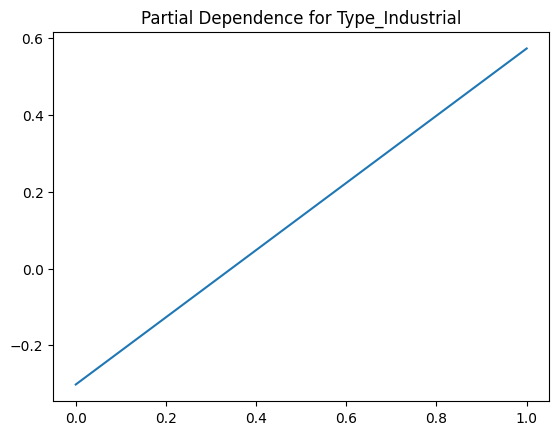

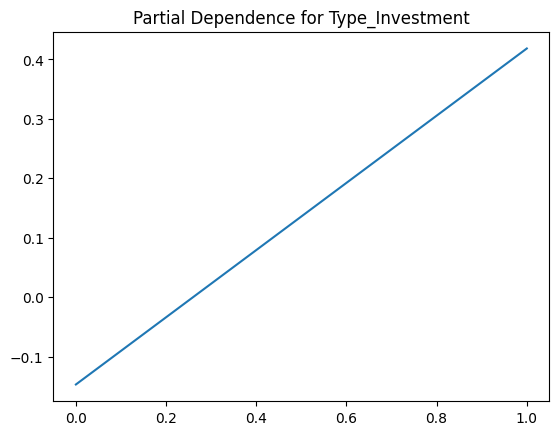

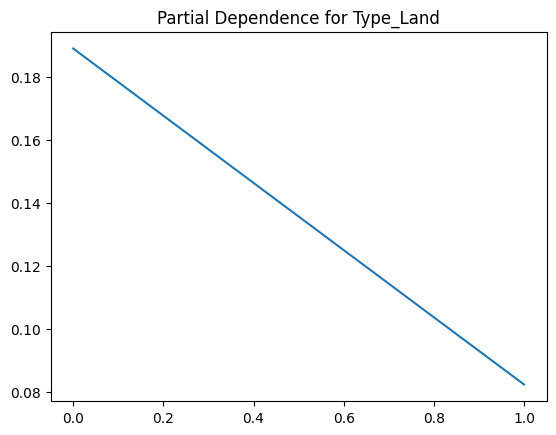

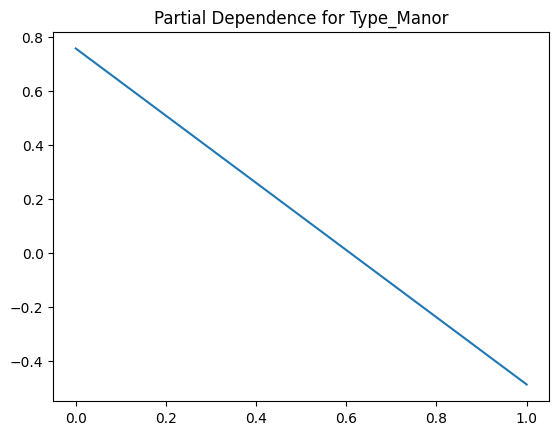

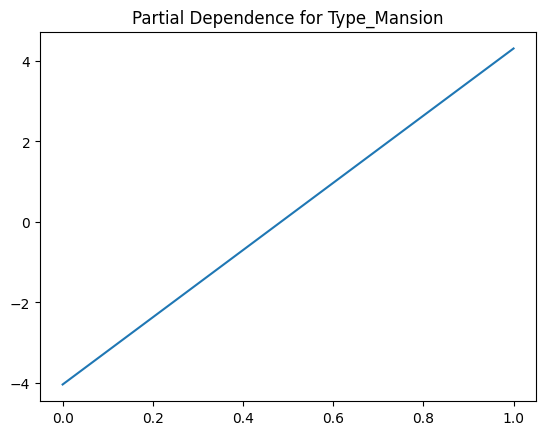

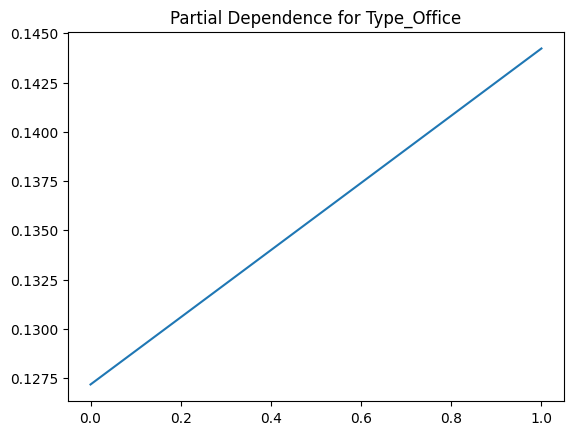

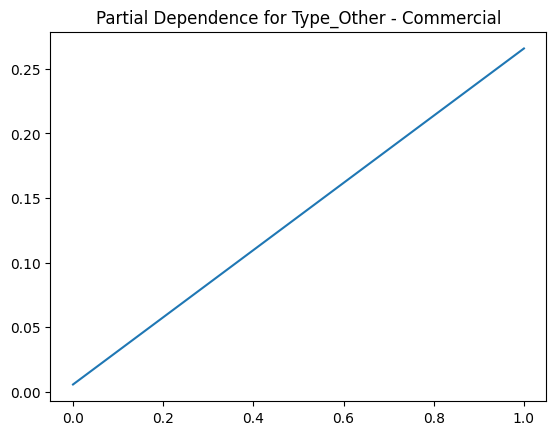

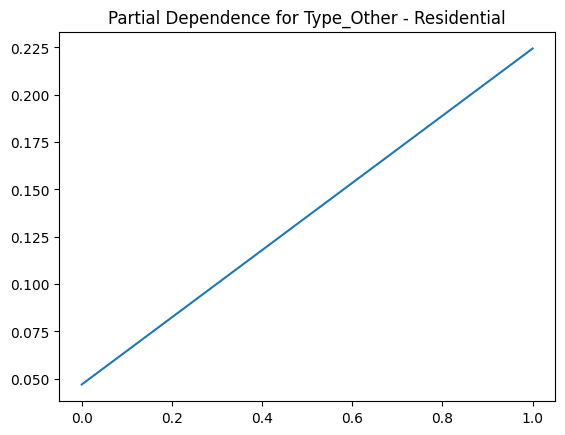

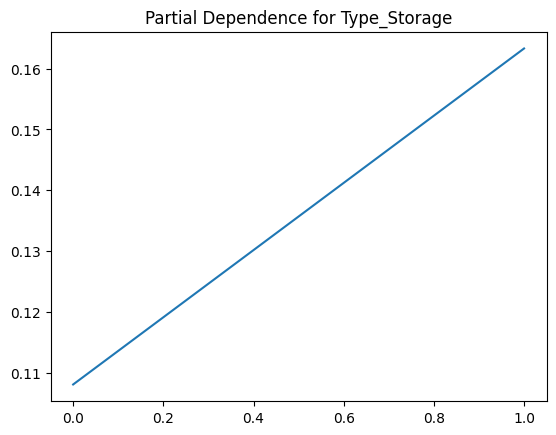

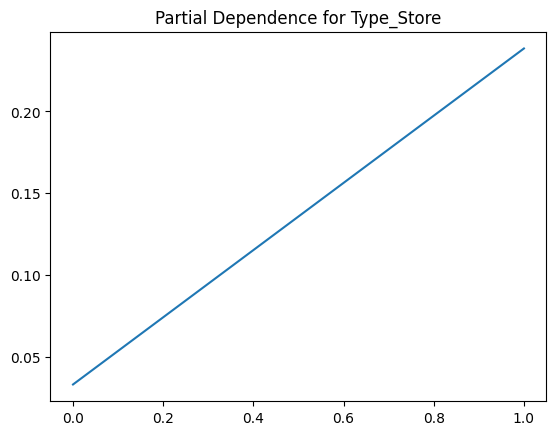

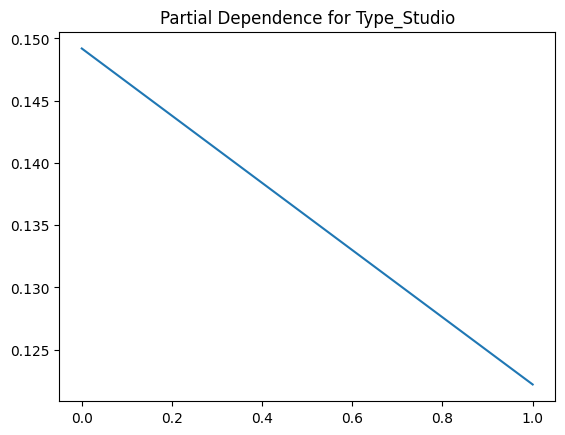

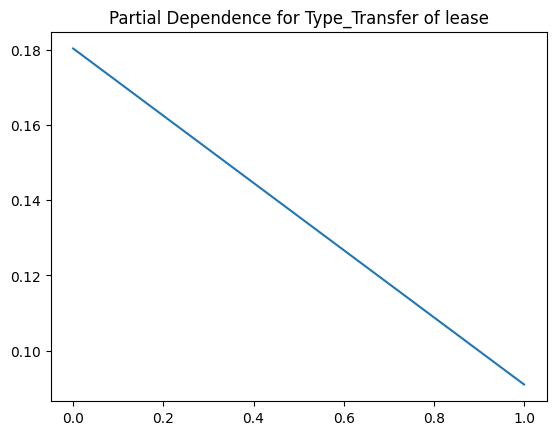

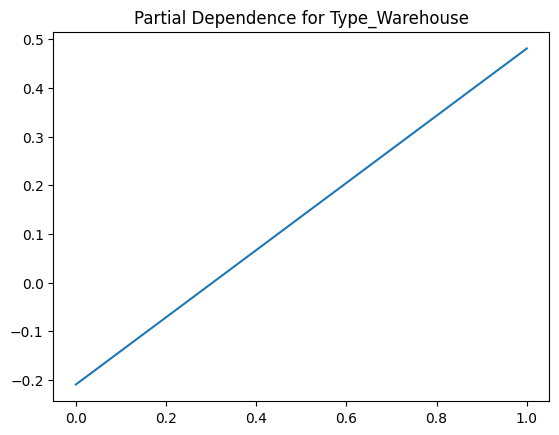

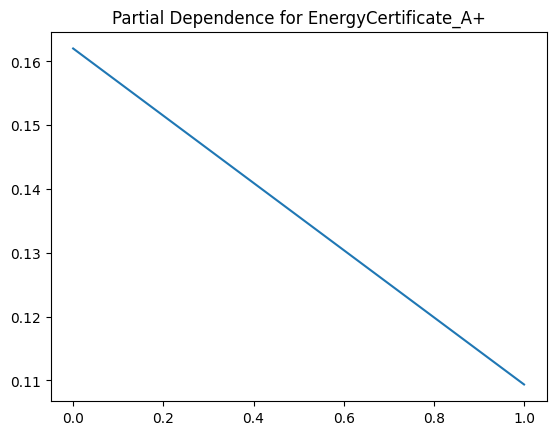

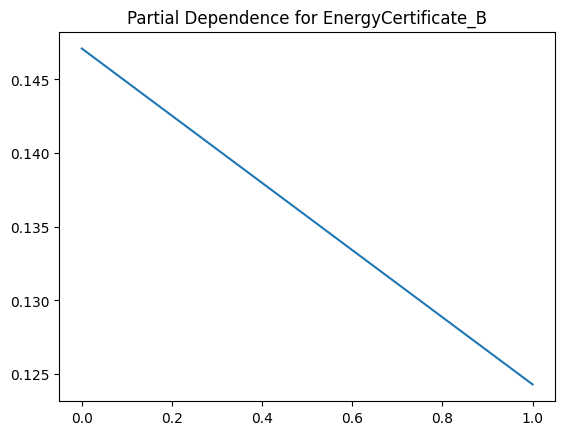

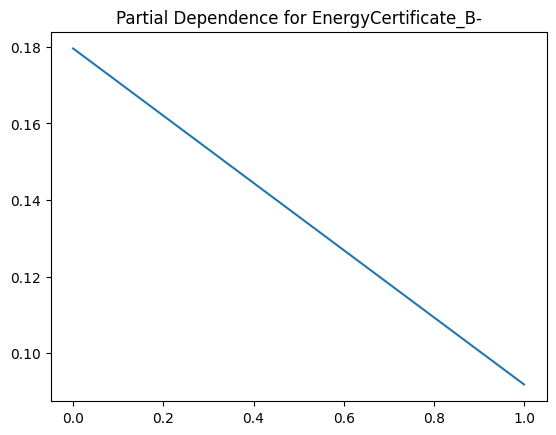

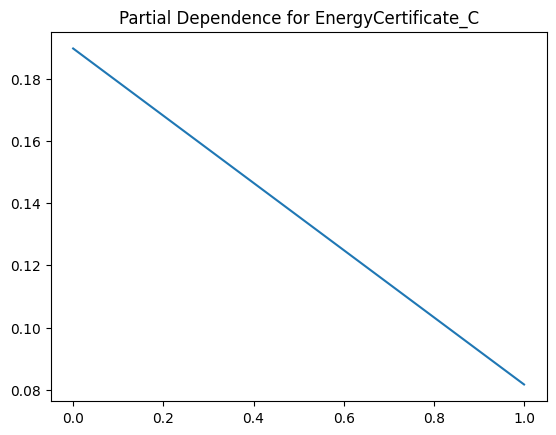

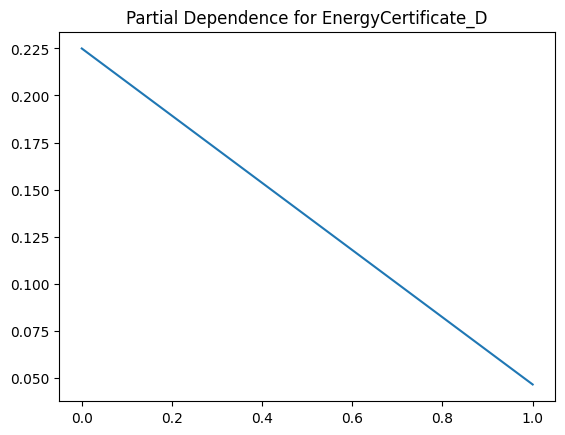

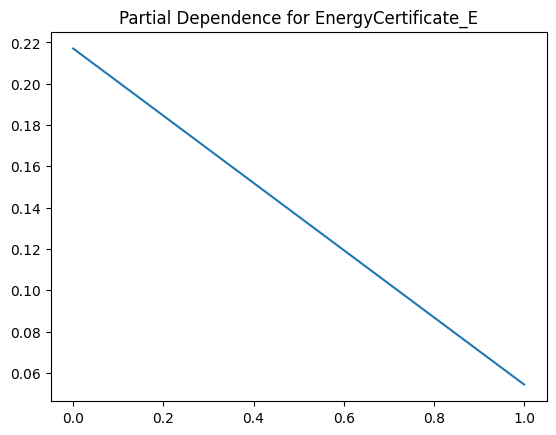

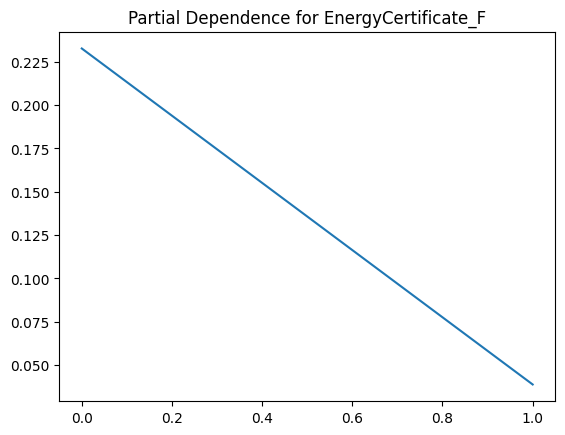

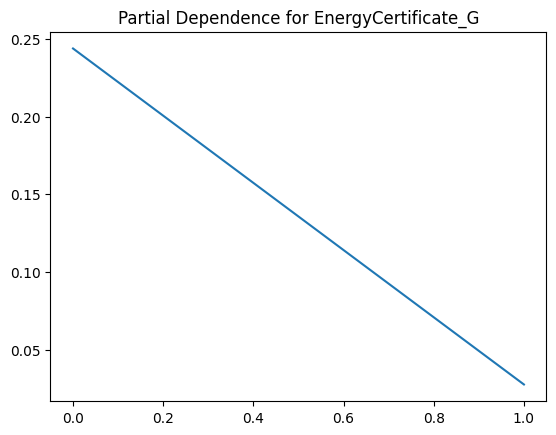

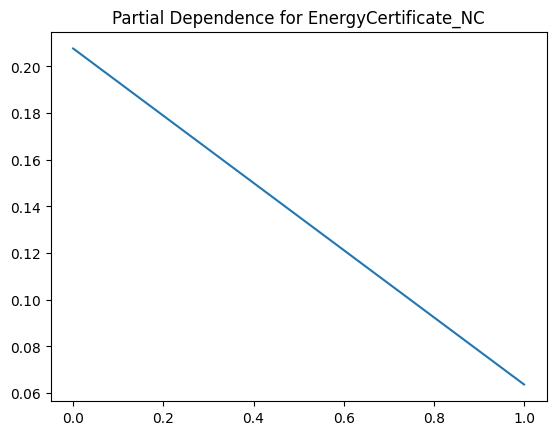

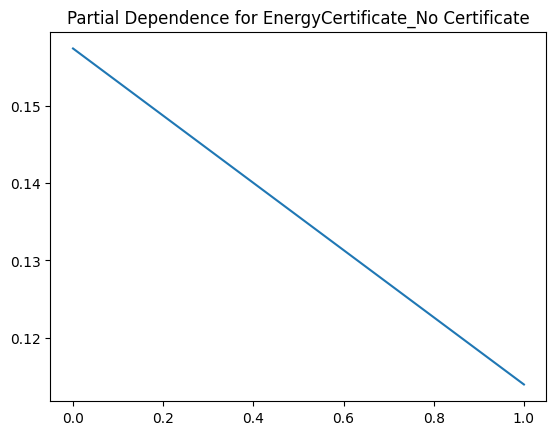

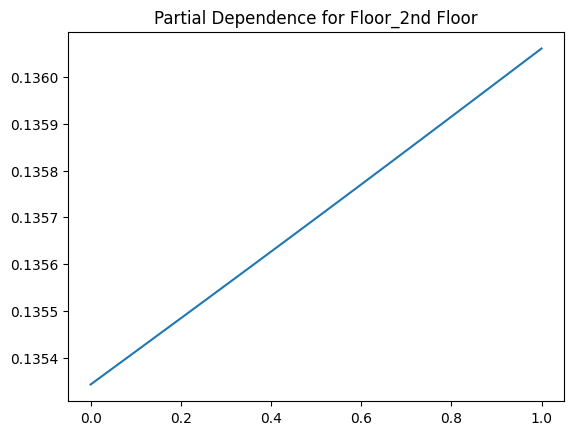

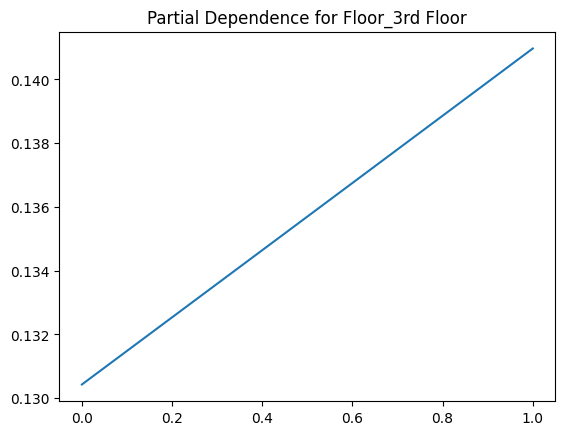

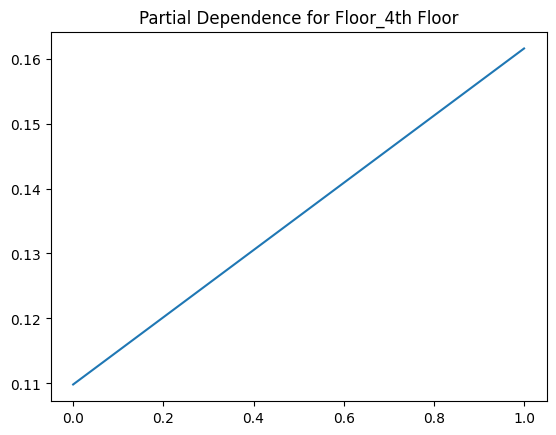

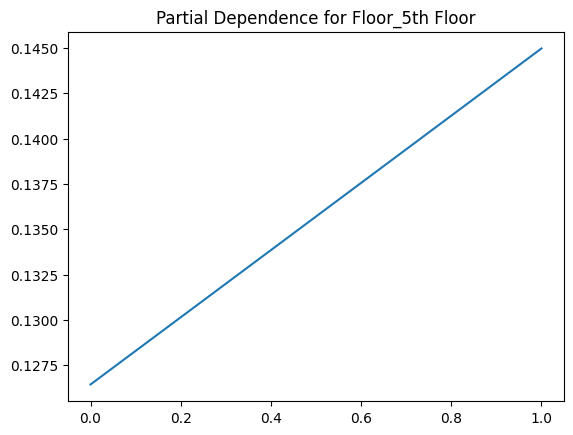

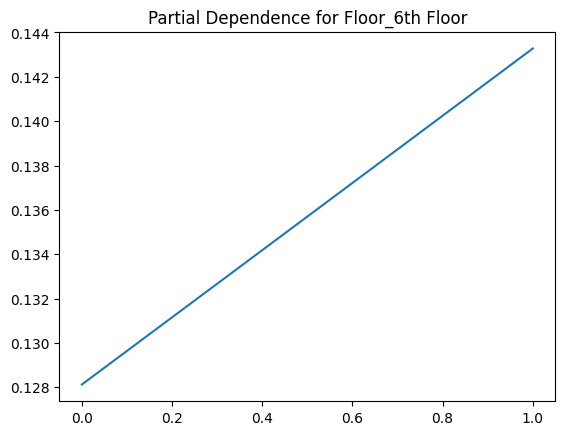

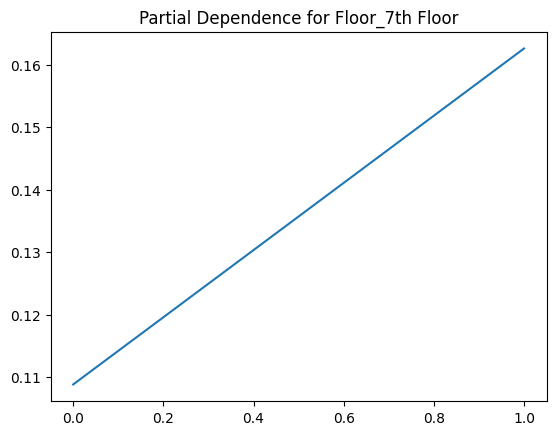

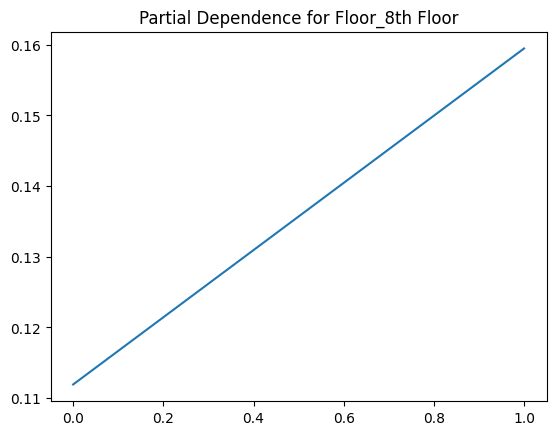

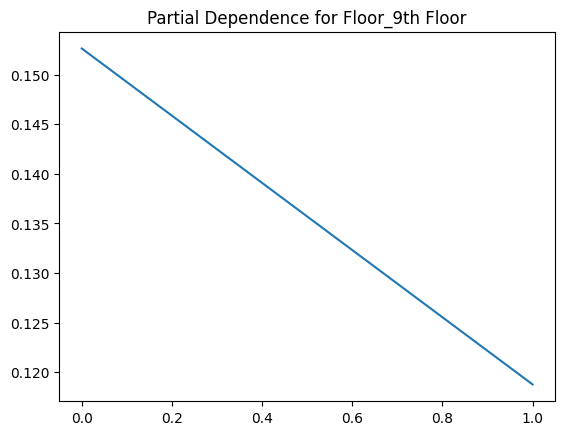

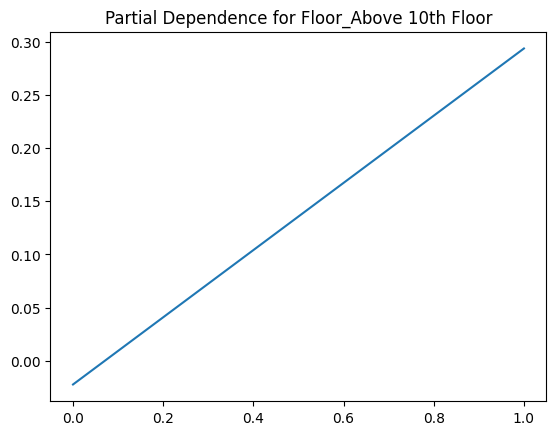

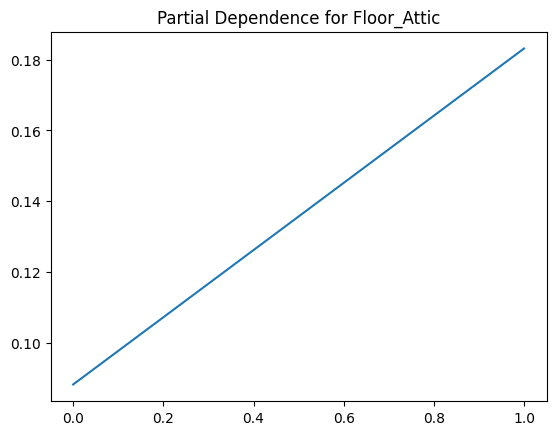

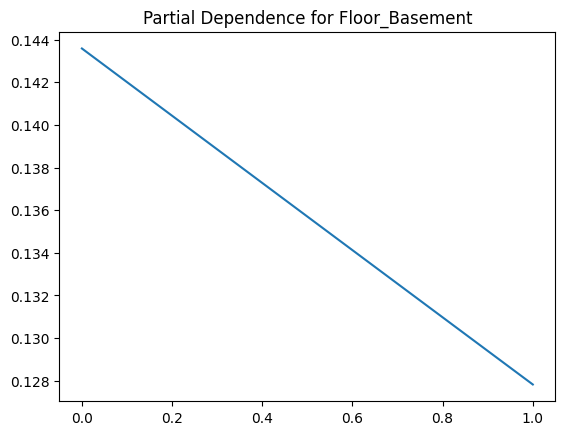

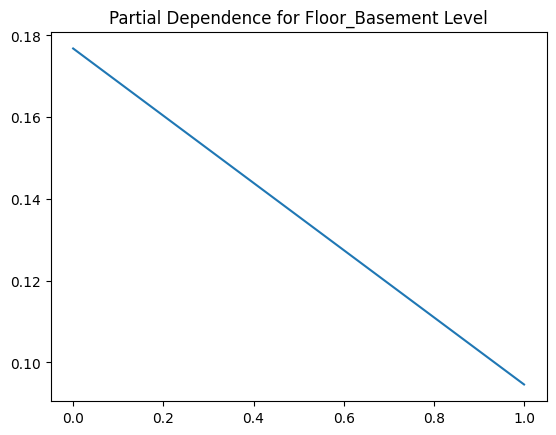

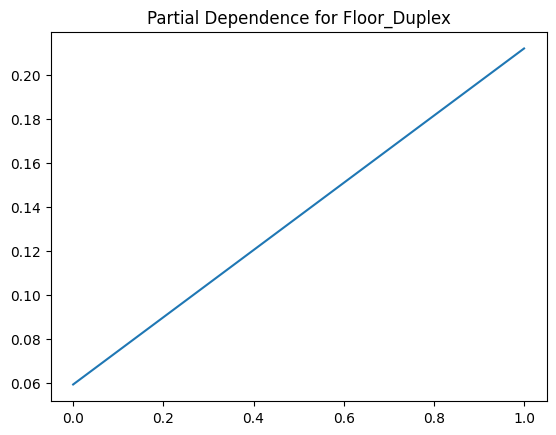

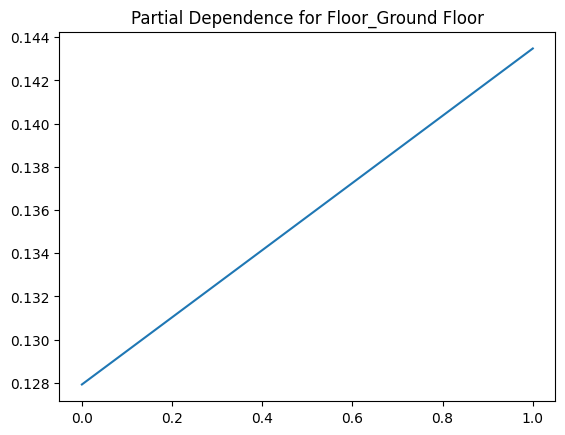

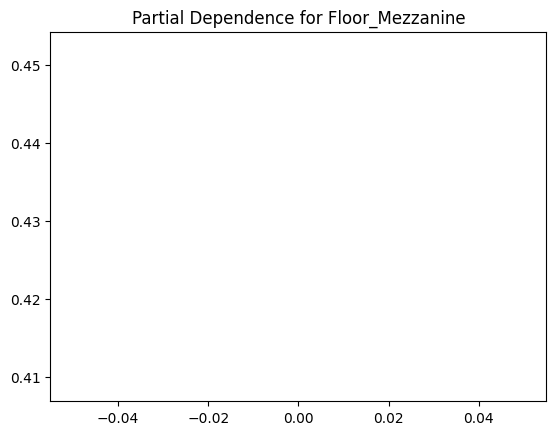

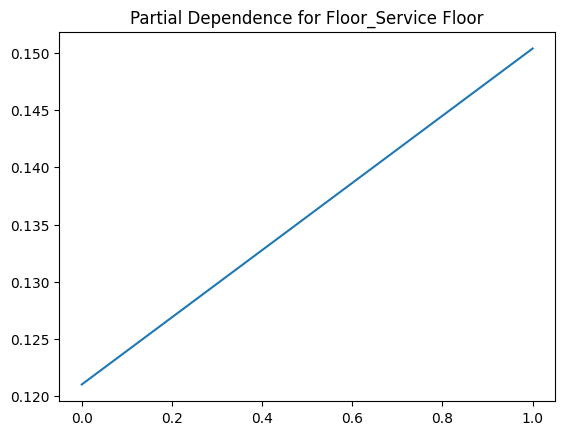

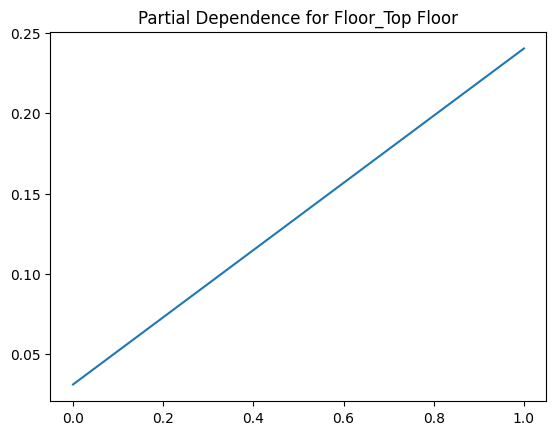

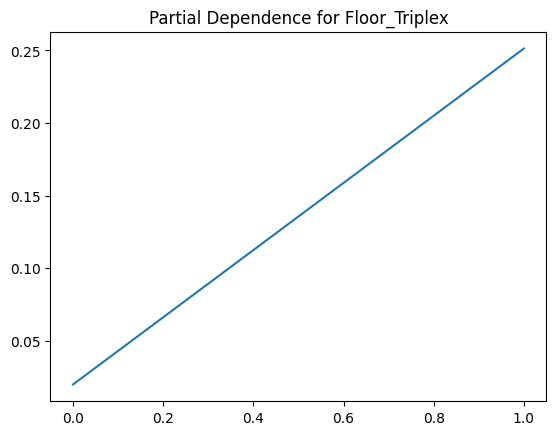

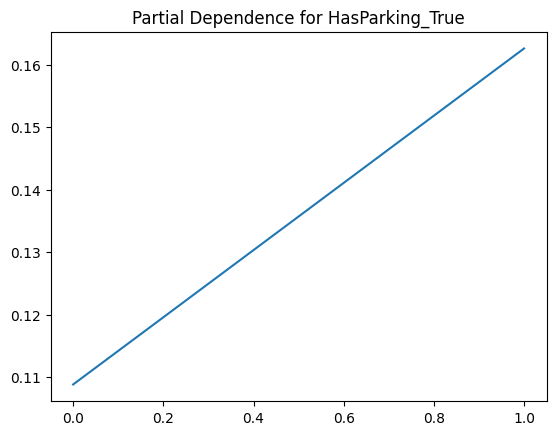

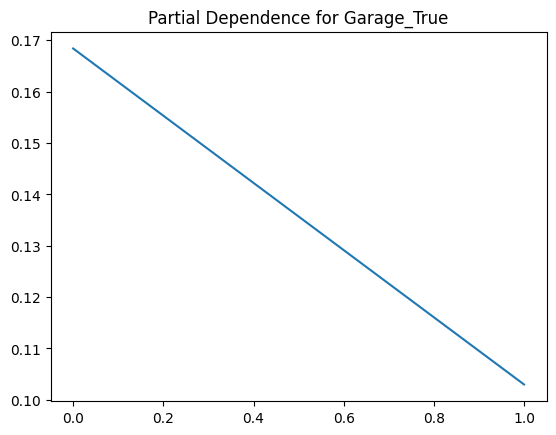

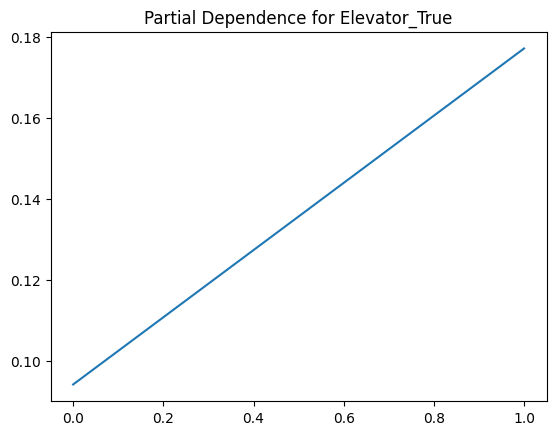

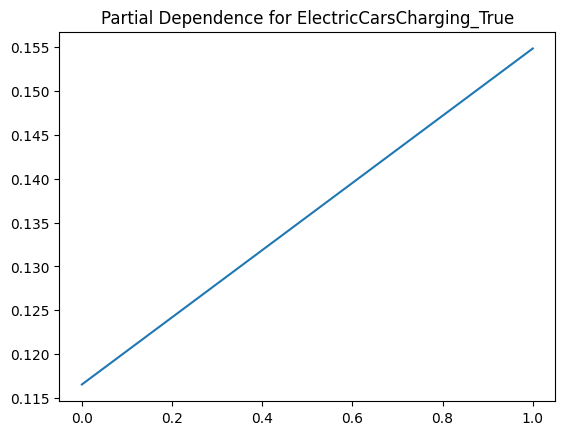

In [37]:
# Plot feature effects
for i, feature_name in enumerate(X_train.columns):
    plt.figure()
    XX = gam.generate_X_grid(term=i)
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f'Partial Dependence for {feature_name}')
    plt.show()

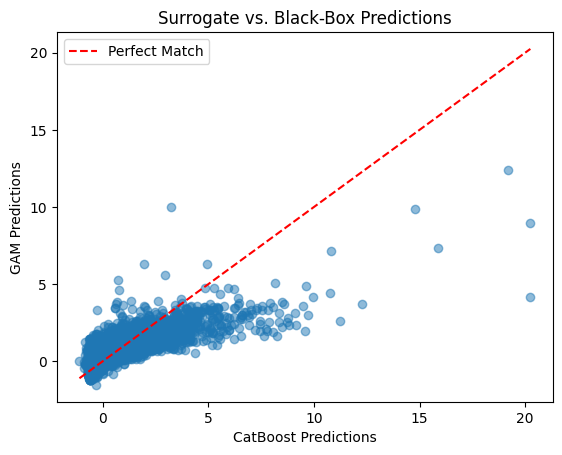

In [38]:
import matplotlib.pyplot as plt

# Scatter plot of GAM predictions vs. CatBoost predictions
plt.scatter(y_pred, y_gam_pred, alpha=0.5)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], color='red', linestyle='--', label='Perfect Match')
plt.title('Surrogate vs. Black-Box Predictions')
plt.xlabel('CatBoost Predictions')
plt.ylabel('GAM Predictions')
plt.legend()
plt.show()


### Conclusions about the surrogate model

## Rule Extraction

In [39]:
from sklearn.tree import DecisionTreeRegressor, export_text

# Fit a decision tree to the GAM predictions
tree = DecisionTreeRegressor(max_depth=3)  # Adjust depth for simplicity
tree.fit(X_test, y_gam_pred)

# Extract and display rules
rules = export_text(tree, feature_names=X_test.columns.tolist())
print(rules)


|--- Town <= 0.56
|   |--- NumberOfBathrooms <= 0.49
|   |   |--- GrossArea <= 2.15
|   |   |   |--- value: [-0.31]
|   |   |--- GrossArea >  2.15
|   |   |   |--- value: [1.01]
|   |--- NumberOfBathrooms >  0.49
|   |   |--- NumberOfBathrooms <= 2.00
|   |   |   |--- value: [0.27]
|   |   |--- NumberOfBathrooms >  2.00
|   |   |   |--- value: [1.22]
|--- Town >  0.56
|   |--- NumberOfBathrooms <= 1.21
|   |   |--- Town <= 1.89
|   |   |   |--- value: [0.40]
|   |   |--- Town >  1.89
|   |   |   |--- value: [1.09]
|   |--- NumberOfBathrooms >  1.21
|   |   |--- LotSize <= 4.75
|   |   |   |--- value: [1.71]
|   |   |--- LotSize >  4.75
|   |   |   |--- value: [9.65]



- Important Features:
    - The first split is on NumberOfBedrooms, suggesting it is the most influential feature in predicting the target.
    - Other key features include Town, TotalRooms, and NumberOfBathrooms.

- Ranges and Predictions:
    - For properties with 3 or fewer bedrooms, predicted values range from $103,072 to $794,933, depending on the Town value.
    - For properties with more than 3 bedrooms, predicted values range from $474,319 to $1,619,001, influenced by both Town, TotalRooms, and NumberOfBathrooms.

- Interpretable Rules:
    - If you want to extract rules from this tree, you can summarize it as:
        - Rule 1: For properties with NumberOfBedrooms <= 3 and Town <= 310,538, the predicted value is approximately $103,072.
        - Rule 2: For properties with NumberOfBedrooms > 3, Town > 525,022, and NumberOfBathrooms > 4.1, the predicted value is approximately $1,619,001.

- Feature Impact:
    - Smaller values of Town and fewer rooms generally lead to lower predictions.
    - Higher values of Town, more rooms, and more bathrooms correspond to higher predictions.

### Global analysis on the task

## Task 3.2
Apply  at  least  two  feature-based  techniques  and  compare  the  insights  obtained  from 
 the explanations generated by the two methods, whether they are consistent or not.

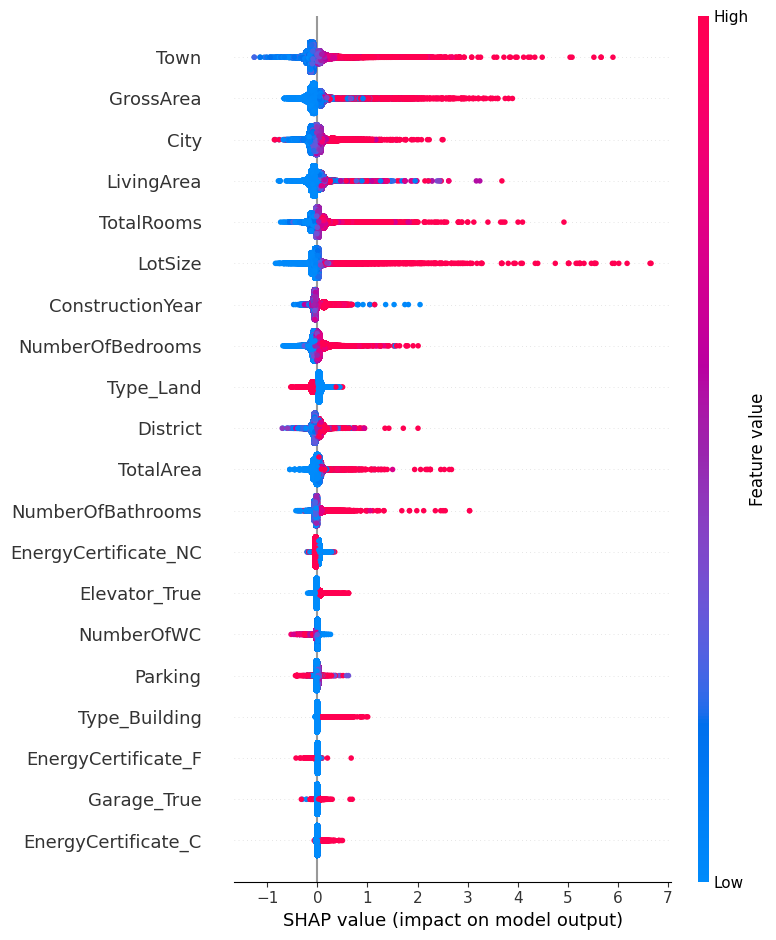

In [40]:
# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X)

# Plot feature importance
shap.summary_plot(shap_values, X)
# Make predictions and evaluate the model

In [41]:
# LIME
import lime
import lime.lime_tabular
# Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)

# Explain a single prediction
i = 0  # Index of the instance to explain
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=catboost_model.predict
)

# Show the explanation
exp.show_in_notebook(show_table=True)

### Global Analysis on the task 3.2

# Task 3.3
 Apply  at  least  one  example-based  technique  and  discuss  the  explanation  obtained  for 
 two different examples

## Factual Explanations: Anchors

In [ ]:
from alibi.explainers import AnchorTabular
import numpy as np

# Define the explainer
explainer = AnchorTabular(predictor=catboost_model.predict, feature_names=X_train.columns)

# Fit the explainer
explainer.fit(X_train.values, disc_perc=[10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95])  # finer discretization

# Select two examples
example_1 = X_test.iloc[8].values
example_2 = X_test.iloc[7].values

# Generate explanations
explanation_1 = explainer.explain(example_1, threshold=0.1)  # Reduce precision threshold to 80%
explanation_2 = explainer.explain(example_2, threshold=0.1)  # Reduce precision threshold to 80%

# Print explanations
print(f"Anchor for Example 1: {explanation_1.anchor}")
print(f"Precision: {explanation_1.precision}")
print(f"Coverage: {explanation_1.coverage}")

print(f"Anchor for Example 2: {explanation_2.anchor}")
print(f"Precision: {explanation_2.precision}")
print(f"Coverage: {explanation_2.coverage}")


Could not find an anchor satisfying the 0.1 precision constraint. Now returning the best non-eligible result. The desired precision threshold might not be achieved due to the quantile-based discretisation of the numerical features. The resolution of the bins may be too large to find an anchor of required precision. Consider increasing the number of bins in `disc_perc`, but note that for some numerical distribution (e.g. skewed distribution) it may not help.
Could not find an anchor satisfying the 0.1 precision constraint. Now returning the best non-eligible result. The desired precision threshold might not be achieved due to the quantile-based discretisation of the numerical features. The resolution of the bins may be too large to find an anchor of required precision. Consider increasing the number of bins in `disc_perc`, but note that for some numerical distribution (e.g. skewed distribution) it may not help.


Anchor for Example 1: ['ElectricCarsCharging_True <= 0.00', '-0.30 < NumberOfBathrooms <= 0.42', 'LotSize <= -0.08', 'LivingArea <= -0.16', 'Floor_2nd Floor <= 0.00', '1.59 < City <= 1.96', '0.83 < Town <= 1.20', 'ConstructionYear <= -1.46', 'GrossArea <= -0.14', 'Type_Warehouse <= 0.00', 'NumberOfWC <= -0.49', 'TotalArea <= -0.01', 'EnergyCertificate_C <= 0.00', '-0.65 < NumberOfBedrooms <= -0.37', 'Floor_5th Floor <= 0.00', '-0.86 < TotalRooms <= -0.48', 'Type_Store <= 0.00', 'Parking <= -0.65', 'Type_Building <= 0.00', 'Type_Transfer of lease <= 0.00', '0.84 < District <= 1.45', 'Type_Other - Residential <= 0.00', 'Type_Office <= 0.00', 'Floor_Ground Floor <= 0.00', 'Type_Storage <= 0.00', 'EnergyCertificate_B <= 0.00', 'EnergyCertificate_G <= 0.00', 'EnergyCertificate_D <= 0.00', 'EnergyCertificate_NC <= 0.00', 'Type_Estate <= 0.00', 'Floor_Above 10th Floor <= 0.00', 'Floor_Triplex <= 0.00', 'Elevator_True <= 0.00', 'Type_Land <= 0.00', 'Type_Garage <= 0.00', 'Type_Studio <= 0.00',

### CounterFactual Explanations: Local Rule-Based

### LORE
Simulating LORE with Decision Trees

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Select a specific instance
instance = X_test.iloc[4].values

# Generate synthetic data around the instance
nn = NearestNeighbors(n_neighbors=100).fit(X_train.values)
neighbors = nn.kneighbors([instance], return_distance=False)

local_data = X_train.values[neighbors[0]]
local_target = (catboost_model.predict(local_data) > 0.5).astype(int)  # Binary target

# Train a decision tree locally
local_tree = DecisionTreeClassifier(max_depth=3)
local_tree.fit(local_data, local_target)

# Extract rules
from sklearn.tree import export_text
rules = export_text(local_tree, feature_names=X_train.columns.tolist())
print(rules)

|--- class: 0

